In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data.csv')

X = df.iloc[:, :2].values
y = df.iloc[:, 2].values

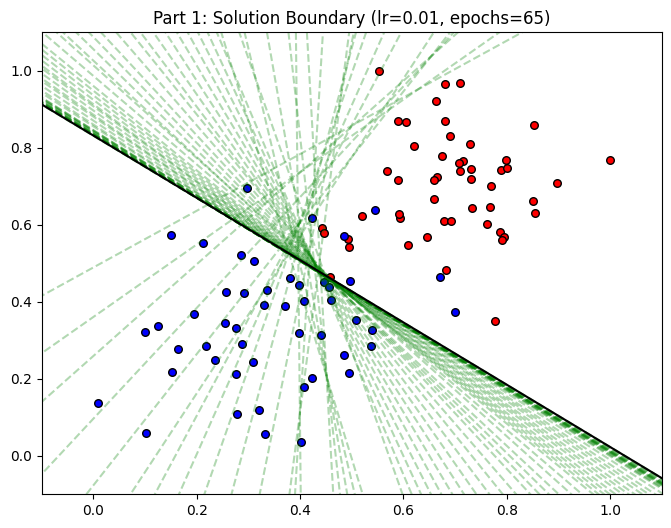

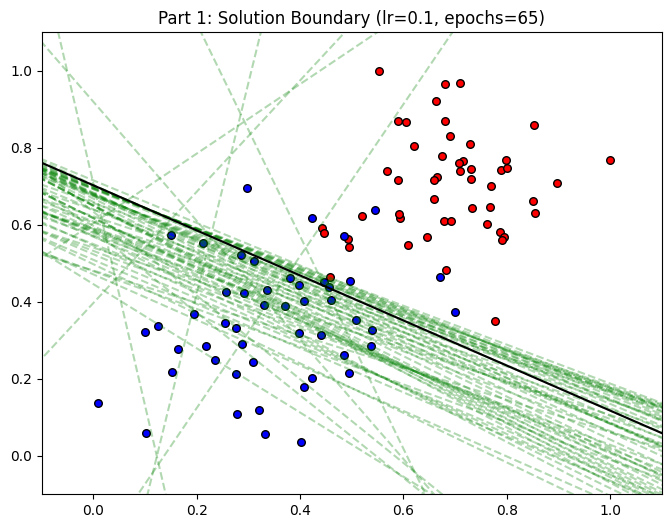

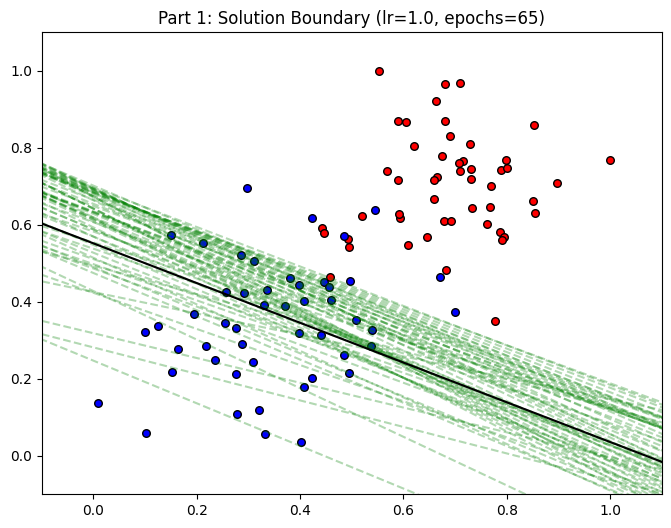

In [ ]:
def plot_boundary(ax, W, b, color, linestyle, alpha=1.0):
    x_vals = np.array([-0.2, 1.2])
    y_vals = -(W[0]*x_vals + b)/W[1]
    ax.plot(x_vals, y_vals, color=color, linestyle=linestyle, alpha=alpha)

def perceptron_heuristic(X, y, lr=0.1, epochs=65):
    np.random.seed(42)
    W = np.random.rand(2)
    b = np.random.rand(1)[0]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(X[y==0][:,0], X[y==0][:,1], c='red', edgecolors='k', s=30)
    ax.scatter(X[y==1][:,0], X[y==1][:,1], c='blue', edgecolors='k', s=30)
    ax.set_title(f'Part 1: Solution Boundary (lr={lr}, epochs={epochs})')
    ax.set_xlim([-0.1, 1.1])
    ax.set_ylim([-0.1, 1.1])
    plot_boundary(ax, W, b, 'red', '-')

    for epoch in range(epochs):
        for i in range(len(X)):
            pred = 1 if (np.dot(W, X[i]) + b) >= 0 else 0

            if pred != y[i]:
                if y[i] == 1:
                    W += lr * X[i]
                    b += lr
                else:
                    W -= lr * X[i]
                    b -= lr

        plot_boundary(ax, W, b, 'green', '--', alpha=0.3)

    plot_boundary(ax, W, b, 'black', '-')
    plt.show()

perceptron_heuristic(X, y, lr=0.01, epochs=65)
perceptron_heuristic(X, y, lr=0.1, epochs=65)
perceptron_heuristic(X, y, lr=1.0, epochs=65)

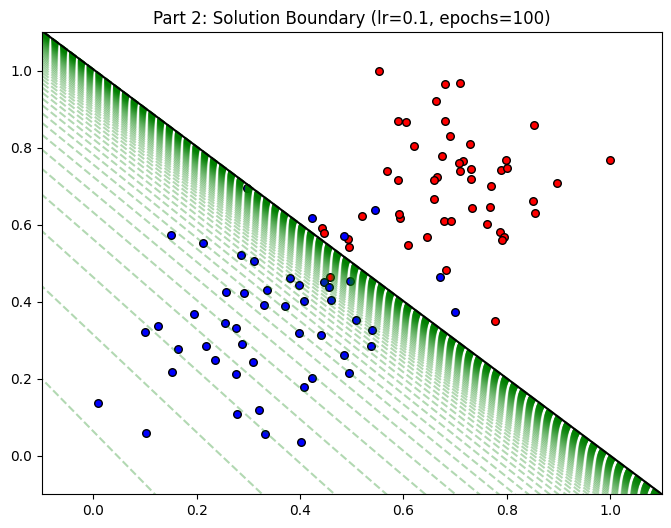

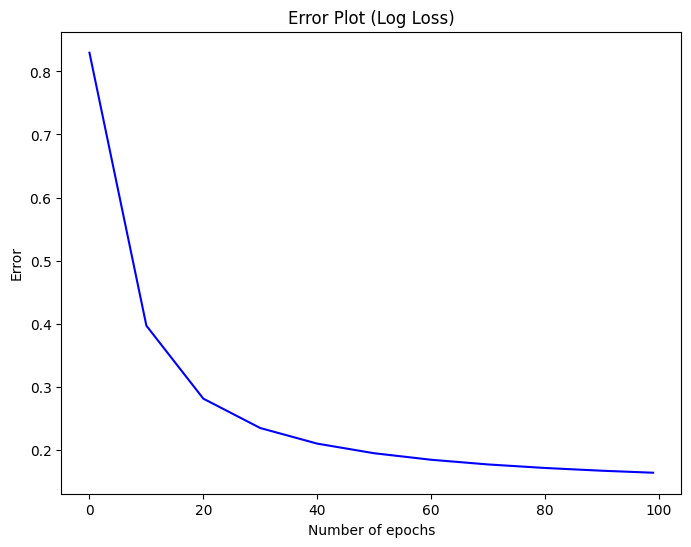

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def perceptron_gradient_descent(X, y, lr=0.1, epochs=100):
    np.random.seed(42)
    W = np.random.rand(2)
    b = np.random.rand(1)[0]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(X[y==0][:,0], X[y==0][:,1], c='red', edgecolors='k', s=30)
    ax.scatter(X[y==1][:,0], X[y==1][:,1], c='blue', edgecolors='k', s=30)
    ax.set_title(f'Part 2: Solution Boundary (lr={lr}, epochs={epochs})')
    ax.set_xlim([-0.1, 1.1])
    ax.set_ylim([-0.1, 1.1])

    plot_boundary(ax, W, b, 'red', '-')
    errors = []
    epoch_list = []

    for epoch in range(epochs):
        for i in range(len(X)):
            y_hat = sigmoid(np.dot(W, X[i]) + b)
            error = y[i] - y_hat

            W += lr * error * X[i]
            b += lr * error

        plot_boundary(ax, W, b, 'green', '--', alpha=0.3)

        if epoch % 10 == 0 or epoch == epochs - 1:
            y_pred_all = sigmoid(np.dot(X, W) + b)
            eps = 1e-15
            y_pred_all = np.clip(y_pred_all, eps, 1 - eps)
            log_loss = -np.mean(y * np.log(y_pred_all) + (1 - y) * np.log(1 - y_pred_all))
            errors.append(log_loss)
            epoch_list.append(epoch)

    plot_boundary(ax, W, b, 'black', '-')
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.plot(epoch_list, errors, 'b-')
    plt.title('Error Plot (Log Loss)')
    plt.xlabel('Number of epochs')
    plt.ylabel('Error')
    plt.show()

perceptron_gradient_descent(X, y, lr=0.1, epochs=100)